In [2]:
# ===========================================================
#  K-MEANS CLUSTERING FOR MHY EARTHQUAKE LABEL COMPARISON
#  Complete Script – Ready to Run
# ===========================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    confusion_matrix,
    adjusted_rand_score,
    normalized_mutual_info_score
)
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# -----------------------------------------------------------
# STEP 1: LOAD DATA
# -----------------------------------------------------------
# Hinglish: Apni synthetic catalog CSV ko load kar lo
catalog = pd.read_csv("/home/ashraf/Desktop/THESIS-FINAL/TRAIN-DATA/mld_final-nz_synthetic_catalog.csv")
df=catalog.copy()
df.head()

,event,DateTime,Date,Year,Month,Day,time,latitude,longitude,magnitude,Generation,ParentID,Label,i+,N+,T+,R+,dm+,n_child,n_parent
0,8,2005-01-01 01:10:00.825848852,2005-01-01,2005,1,1,0.048621,-37.396225,177.987203,3.301688,0,NaN,background,0,2.097547e-04,0.000694,3.021055e-01,0.176485,0.036315,0.036315
1,41,2005-01-01 05:42:37.953139645,2005-01-01,2005,1,1,0.237939,-37.124231,177.535453,3.163747,1,1754.0,triggered,1,2.702490e-05,0.003774,7.160450e-03,0.137941,0.036315,0.036315
2,46,2005-01-01 05:43:05.509842873,2005-01-01,2005,1,1,0.238258,-37.123676,177.537697,3.500583,1,1754.0,triggered,2,1.064500e-11,0.000007,1.421550e-06,-0.336836,0.072630,0.036315
3,47,2005-01-01 05:43:17.946950013,2005-01-01,2005,1,1,0.238402,-42.631090,167.284364,3.736844,0,NaN,background,3,1.811590e-06,0.000002,7.991986e-01,-0.236261,0.000000,0.072630
4,48,2005-01-01 05:43:23.387341987,2005-01-01,2005,1,1,0.238465,-37.123590,177.536278,3.048787,1,1754.0,triggered,3,1.428314e-12,0.000003,4.383602e-07,0.451797,0.036315,0.072630


In [3]:
df.columns

Index(['event', 'DateTime', 'Date', 'Year', 'Month', 'Day', 'time', 'latitude',
       'longitude', 'magnitude', 'Generation', 'ParentID', 'Label', 'i+', 'N+',
       'T+', 'R+', 'dm+', 'n_child', 'n_parent'],
      dtype='object')

In [6]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    confusion_matrix, adjusted_rand_score, normalized_mutual_info_score,
    silhouette_score
)
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns


============ METRICS ============
Confusion Matrix:
 [[ 3934 25737]
 [ 1165 69667]]
ARI: 0.09308769511227542
NMI: 0.06452269551146098
Silhouette Score: 0.7046194544723429
Purity: 0.9492651960637991

Cluster vs True Label:
Label       background  triggered
cluster_id                       
0                 3934       1165
1                25737      69667


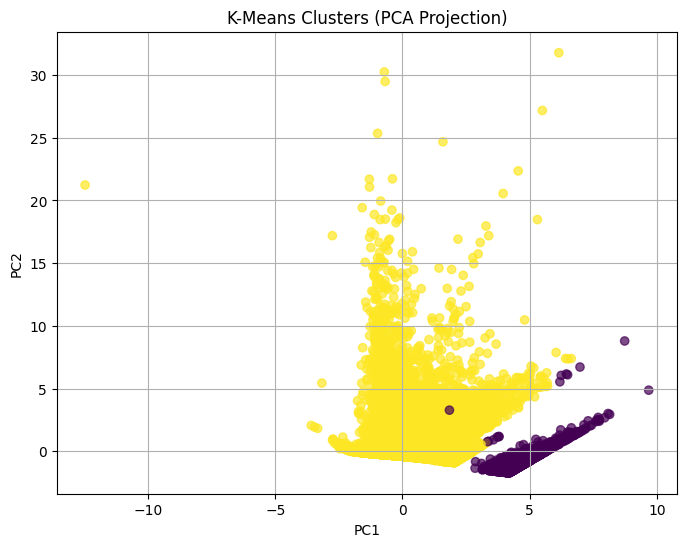

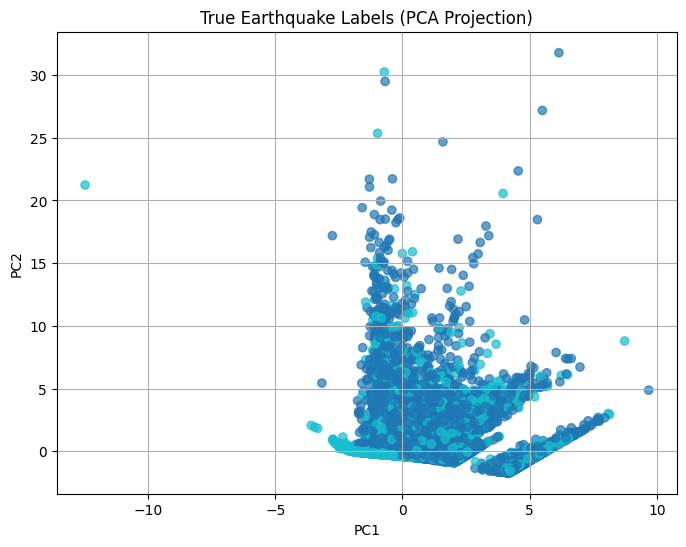

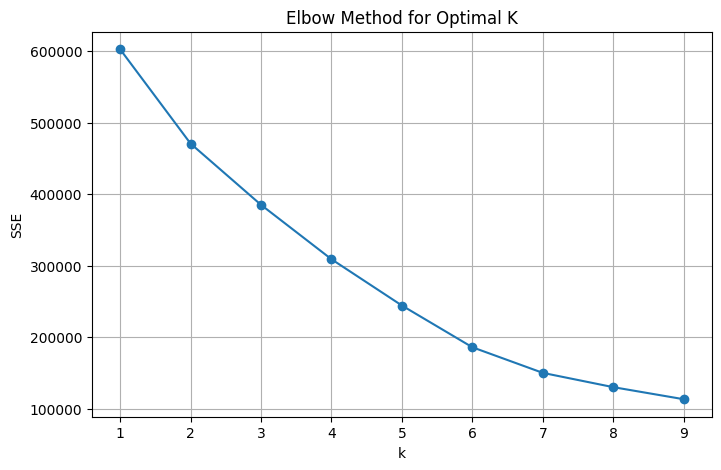


Feature Importances (via Random Forest surrogate):
    Feature  Importance
5  n_parent    0.657219
3       dm+    0.273687
1        T+    0.041186
2        R+    0.014156
0        N+    0.012854
4   n_child    0.000897


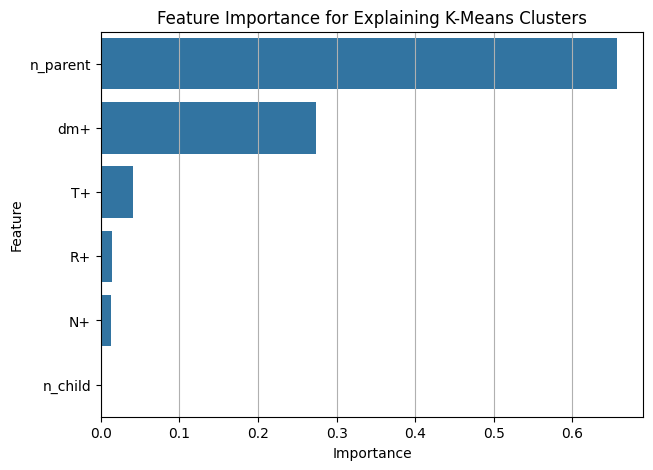


Saved full output as events_full_results.csv


In [9]:
# ===========================================================
# MASTER SCRIPT: K-MEANS + COMPLETE VALIDATION + VISUALIZATION
# ===========================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    confusion_matrix, adjusted_rand_score, normalized_mutual_info_score,
    silhouette_score
)
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------

# -----------------------------------------------------------
# STEP 2: SELECT FEATURES
# -----------------------------------------------------------
features = ['N+', 'T+', 'R+', 'dm+','n_child', 'n_parent']
X = df[features]
y_true_str = df['Label']

# Convert true labels to numeric for accuracy comparison
label_map = {label: idx for idx, label in enumerate(y_true_str.unique())}
y_true = y_true_str.map(label_map)

# -----------------------------------------------------------
# STEP 3: SCALE FEATURES
# -----------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------------------------------------
# STEP 4: K-MEANS CLUSTERING
# -----------------------------------------------------------
k = y_true_str.nunique()   # number of true classes
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
cluster_id = kmeans.fit_predict(X_scaled)
df['cluster_id'] = cluster_id

# -----------------------------------------------------------
# STEP 5: METRIC CALCULATIONS
# -----------------------------------------------------------
cm = confusion_matrix(y_true, cluster_id)
ari = adjusted_rand_score(y_true, cluster_id)
nmi = normalized_mutual_info_score(y_true, cluster_id)
sil = silhouette_score(X_scaled, cluster_id)

# Purity Metric
def purity_score(cm):
    return np.sum(np.max(cm, axis=1)) / np.sum(cm)

purity = purity_score(cm)

print("\n============ METRICS ============")
print("Confusion Matrix:\n", cm)
print("ARI:", ari)
print("NMI:", nmi)
print("Silhouette Score:", sil)
print("Purity:", purity)

# Crosstab
print("\nCluster vs True Label:")
print(pd.crosstab(df['cluster_id'], df['Label']))

# -----------------------------------------------------------
# STEP 6: PCA PLOTS
# -----------------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# Plot 1: K-means clusters
plt.figure(figsize=(8,6))
plt.scatter(df['PC1'], df['PC2'], c=df['cluster_id'], cmap='viridis', alpha=0.7)
plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.grid(True)
plt.show()

# Plot 2: True Labels
plt.figure(figsize=(8,6))
plt.scatter(df['PC1'], df['PC2'], c=y_true, cmap='tab10', alpha=0.7)
plt.title("True Earthquake Labels (PCA Projection)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.grid(True)
plt.show()

# -----------------------------------------------------------
# STEP 7: ELBOW METHOD PLOT
# -----------------------------------------------------------
sse = []
K_range = range(1, 10)
for kk in K_range:
    km = KMeans(n_clusters=kk, random_state=42, n_init=20)
    km.fit(X_scaled)
    sse.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, sse, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("k")
plt.ylabel("SSE")
plt.grid(True)
plt.show()

# -----------------------------------------------------------
# STEP 8: FEATURE IMPORTANCE (SURROGATE MODEL)
# -----------------------------------------------------------
# We use a supervised RandomForest to see which features separate clusters best
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_scaled, cluster_id)

importances = rf.feature_importances_
fi_df = pd.DataFrame({'Feature': features, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

print("\nFeature Importances (via Random Forest surrogate):")
print(fi_df)

# Plot Feature Importance
plt.figure(figsize=(7,5))
sns.barplot(x='Importance', y='Feature', data=fi_df)
plt.title("Feature Importance for Explaining K-Means Clusters")
plt.grid(True, axis='x')
plt.show()

# -----------------------------------------------------------
# STEP 9: SAVE FINAL OUTPUT
# -----------------------------------------------------------
df.to_csv("events_full_results.csv", index=False)
print("\nSaved full output as events_full_results.csv")


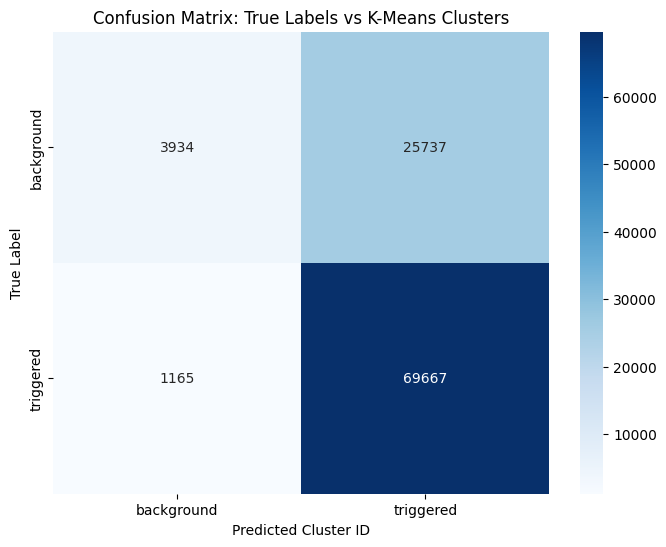

In [10]:
# Plot confusion matrix heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_map.keys(),
            yticklabels=label_map.keys())
plt.title("Confusion Matrix: True Labels vs K-Means Clusters")
plt.xlabel("Predicted Cluster ID")
plt.ylabel("True Label")
plt.show()